# Vectorless RAG
> RAG without Vector DB, without Embeddings, without GPU

We search documents using BM25, pick the best ones, give them to the LLM, and it generates the answer.

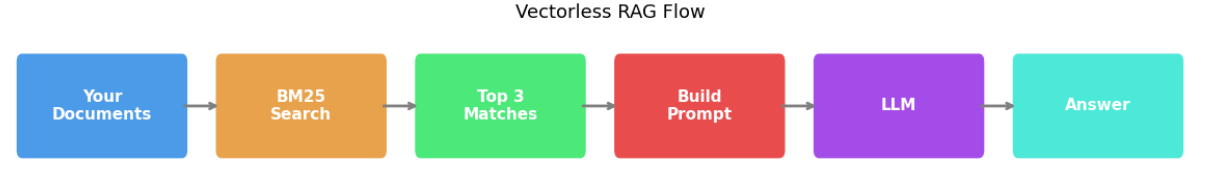

document -> BM25 Search-> TOP Matches -> Prompt-> LLM -> Answer

In [31]:
!pip install rank-bm25 python-dotenv groq -q



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from rank_bm25 import BM25Okapi
DOCS = [
    {"title": "Python",           "content": "Python is a simple high-level programming language."},
    {"title": "Machine Learning", "content": "ML models learn patterns from data using algorithms."},
    {"title": "RAG",              "content": "RAG fetches relevant documents and sends them to an LLM."},
    {"title": "BM25",             "content": "BM25 ranks documents by keyword frequency. No embeddings needed."},
    {"title": "Django",           "content": "Django is a Python web framework with built-in admin and ORM."},
]

# List of doc (your knowledge base)

bm25 =  BM25Okapi([d["content"].lower().split() for d in DOCS])
# Emaple:- "python is simple"->["python", "is", "simple"]
print("Ready! Docs:", [d["title"] for d in DOCS])

Ready! Docs: ['Python', 'Machine Learning', 'RAG', 'BM25', 'Django']


In [33]:
def ask(query): # function to ask the Question
    scores  = bm25.get_scores(query.lower().split())
    # convert query to lower case and split into words
    # BM25 calculate  scores for each document


    top = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:2]
    # sort doc indices based on scores (higher score 1st)
    # pick up 2 docs

    matches = [DOCS[i] for i in top if scores[i] > 0]
    # select docs with score > 0  

    if not matches:
        # if no relavent document found
        print(f"Q: {query}\nA: Not in knowledge base.\n"); return

    # print query
    # 1. user query
    # 2. Retrieved doc titles
    # 3. Answer    
    print(f"Q: {query}\n   Retrieved: {[m['title'] for m in matches]}\nA: {matches[0]['content']}\n")

    
ask("What is BM25?")
ask("Tell me about Django")
ask("What is quantum computing?")  # not in docs

Q: What is BM25?
   Retrieved: ['Python', 'Django']
A: Python is a simple high-level programming language.

Q: Tell me about Django
   Retrieved: ['Django']
A: Django is a Python web framework with built-in admin and ORM.

Q: What is quantum computing?
   Retrieved: ['Python', 'Django']
A: Python is a simple high-level programming language.



In [35]:
# Real LLM via Groq - reads GROQ_API_KEY from .env file
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

# This function takes a user  question and return the answer from LLM
def ask_llm(query):
    # STEP 1 : Score docs using BM25
    score = bm25.get_scores(query.lower().split())

    # STEP 2 : Pick top 2 docs with highest scores
    top = sorted(
        range(len(score)), 
        key=lambda i: score[i], 
        reverse=True
    )[:2]

    # STEP 3 : buid context from retrieved docs
    # Only include docs with score > 0 (RELEVANT)

    context = " | ".join(DOCS[i]["content"] for i in top if score[i] > 0)

    # STEP 4 :  create prompt for LLM
    # we force the model to only use given context to answer the question
    prompt  = f"Answer using only this context: {context}\n\nQ: {query}"

    #STEP 5 : Call LLM Api
    res = Groq(
        api_key=os.getenv("GROQ_API_KEY")
        ).chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
            )

    # STEP 6 : Print the answer from LLM
    print(f"Q: {query}\nA: {res.choices[0].message.content}")

# STEP 7: TEST  the function
ask_llm("Tell me about Django")

Q: Tell me about Django
A: Django is a high-level Python web framework that enables rapid and secure development of web applications. It provides an object-relational mapping (ORM) system, which abstracts the underlying database from the application's code. This simplifies database interactions and makes it easier to work with multiple databases.

One of the key features of Django is its built-in admin interface. The admin interface provides a simple way to manage database content and perform common administrative tasks, such as user management and content creation.

Django follows the Model-View-Controller (MVC) architecture pattern, but with a twist. It uses the Model-View-Template (MVT) pattern, where:

- Models represent the data and business logic
- Views handle HTTP requests and return HTTP responses
- Templates are used for rendering dynamic web pages

Django includes a robust set of libraries and tools for handling tasks such as:

- URL routing and dispatching
- Authentication 